In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("cardata.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [5]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 2


In [6]:
df.drop_duplicates(inplace=True)
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [7]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

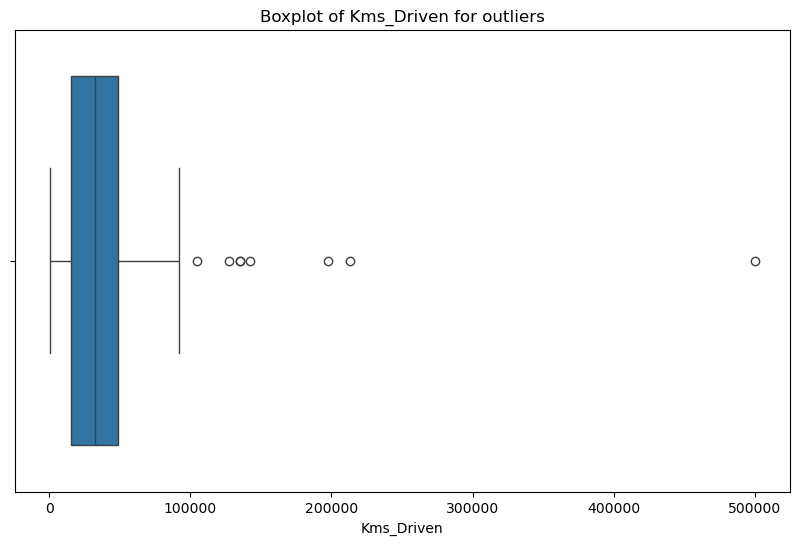

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Kms_Driven'])
plt.title("Boxplot of Kms_Driven for outliers")
plt.show()

In [10]:
Q1=df['Selling_Price'].quantile(0.5)
Q3=df['Selling_Price'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

df_cleaned=df[(df['Selling_Price']>=lower_bound)&(df['Selling_Price']<=upper_bound)]

In [11]:
df_cleaned

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0


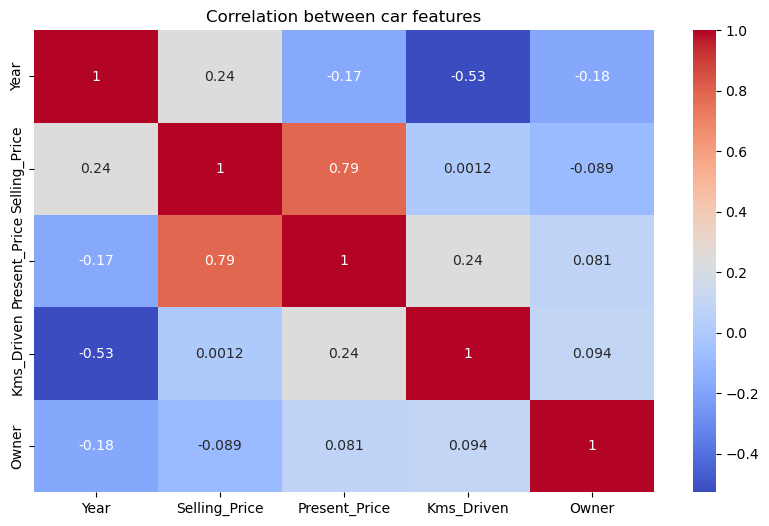

In [12]:
plt.figure(figsize=(10,6))
numerical_df=df_cleaned.select_dtypes(include=['number'])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between car features")
plt.show()

C:\Users\Harshith\AppData\Local\Temp\ipykernel_26108\2960239363.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fuel_Type', y='Selling_Price', data=df_cleaned, palette='viridis')


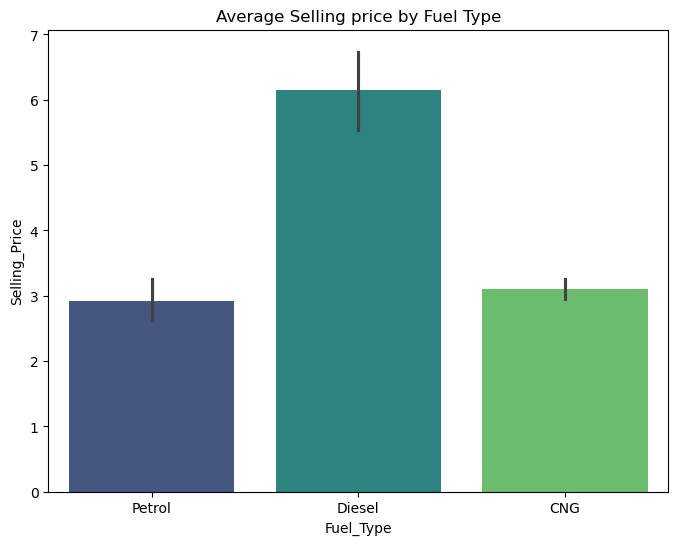

In [13]:
plt.figure(figsize=(8,6))
sns.barplot(x='Fuel_Type', y='Selling_Price', data=df_cleaned, palette='viridis')
plt.title("Average Selling price by Fuel Type")
plt.show()

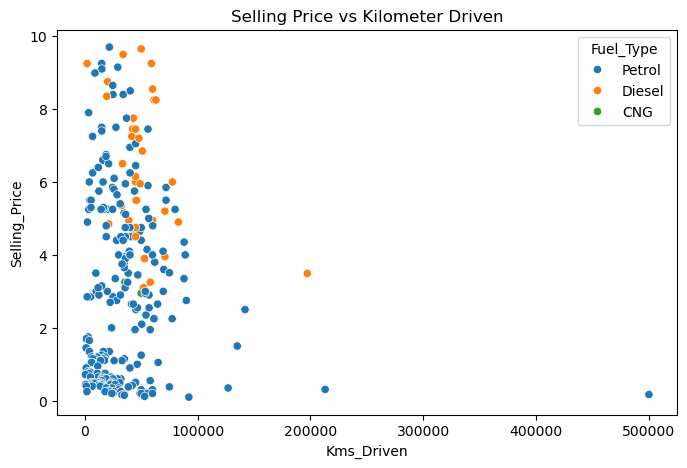

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Kms_Driven", y="Selling_Price", data=df_cleaned, hue="Fuel_Type")
plt.title("Selling Price vs Kilometer Driven")
plt.show()

## Insights

#### Heatmap: It shows that the original showroom price is the most important factor in deciding a car's selling price. It also shows that older cars usually have higher mileage.
#### Bar Plot: It shows that Diesel cars are sold for higher prices than Petrol and CNG cars on average.
#### Scatter Plot: It shows that most cars have been driven less than 100,000 km. It also shows that as the kilometers driven increase, the selling price usually decreases. One car with very high mileage (around 500,000 km) is an outlier and has a very low selling price.